# **Reasons Behind Low Customers Ratings (LCR):**

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
data= pd.read_json("data.json")

In [4]:
data.shape

(10999, 12)

In [5]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [6]:
data.head(3)

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


> In this analysis, we focus on the `Customer_ratings` and try to improve customer satisfaction.

## **11. Distribution of Customer Ratings:**

In [7]:
data["customer_rating"].head(4)

0    2
1    5
2    2
3    3
Name: customer_rating, dtype: int64

In [8]:
data["customer_rating"].unique()

array([2, 5, 3, 1, 4])

In [11]:
cus_rat= data["customer_rating"].value_counts().reset_index()
cus_rat

,customer_rating,count
0,3,2239
1,1,2235
2,4,2189
3,5,2171
4,2,2165


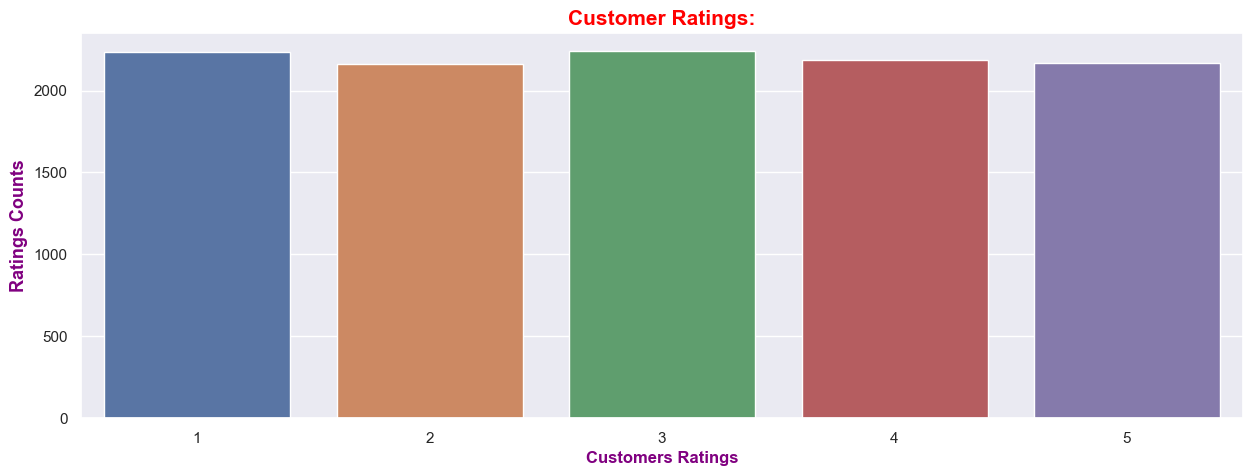

In [18]:
plt.figure(figsize= (15, 5))
sns.set_theme(context= "notebook", style= "darkgrid", palette= "deep")
sns.barplot(data= cus_rat, x= "customer_rating", y= "count", palette= "deep", hue= "customer_rating", legend=False)
plt.title("Customer Ratings:", fontsize= 15, fontweight= "bold", color= "red", loc= "center")
plt.xlabel("Customers Ratings", fontsize= 12, fontweight= "bold", color= "purple")
plt.ylabel("Ratings Counts", fontsize= 13, fontweight= "bold", color= "purple")
plt.show()

SO, there is no high-disbalance in the number of ratings for each rating class. 

---
---
---

## **12. Correlation between Late Deliveries and Ratings:**

In [21]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

To know the linear/ monotonic relation between columns "reached_on_time" and "customer_rating", we can calculate the correlation between them:

In [23]:
data[["reached_on_time", "customer_rating"]].corr(method= "pearson")

,reached_on_time,customer_rating
reached_on_time,1.000000,0.013119
customer_rating,0.013119,1.000000


This shows a very low positive correlation and so there is almost no linear relationship between `reached_on_time` and `customer_rating`.

Since the correlation is close to 0, we can conclude that being "on time" in reaching a customer does not significantly affect their ratings. 

There are various other factors affecting the ratings of products and modeling this relation linearly with `"product on-time delivery"` don't clearly explain their true dependency and influence.

**Check if Late Deliveries Affects Customers Ratings:**

In [37]:
late_del= data.groupby(by= "reached_on_time")["customer_rating"].value_counts(normalize= True).reset_index()
late_del

,reached_on_time,customer_rating,proportion
0,0,1,0.207845
1,0,2,0.201082
2,0,4,0.199729
3,0,3,0.198828
4,0,5,0.192516
5,1,3,0.206765
6,1,5,0.200670
7,1,1,0.200061
8,1,4,0.198537
9,1,2,0.193966


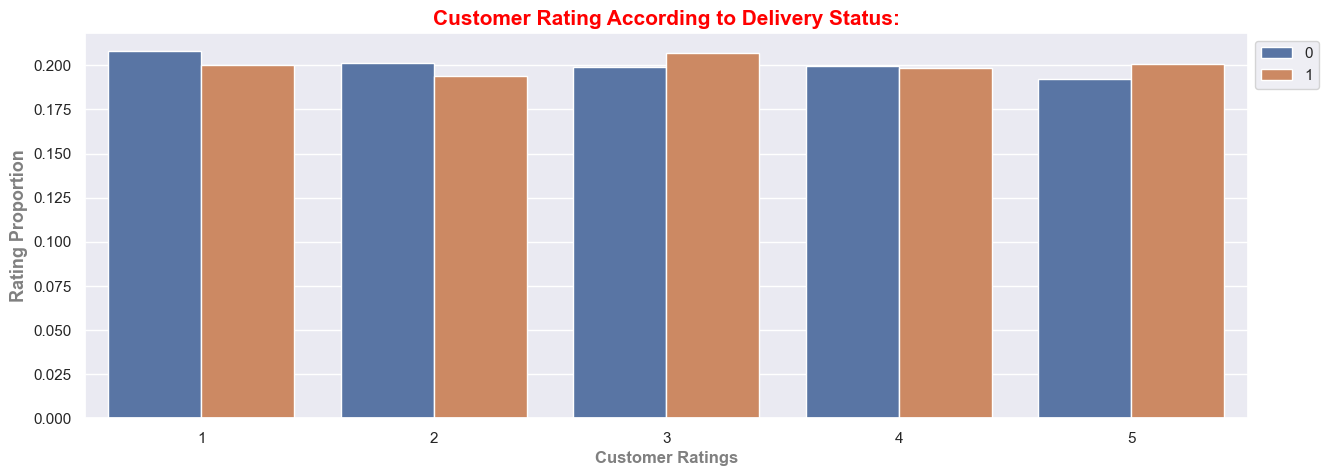

In [38]:
plt.figure(figsize= (15, 5))
sns.barplot(data= late_del, x= "customer_rating", y= "proportion", hue= "reached_on_time")
# Plot legend outside the plot to avoide overlapping: 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Customer Rating According to Delivery Status:", color= "red", fontsize= 15, fontweight= "bold")
plt.xlabel("Customer Ratings", color= "gray", fontweight= "bold", fontsize= 12)
plt.ylabel("Rating Proportion", color= "gray", fontsize= 13, fontweight= "bold")
plt.show()

In [39]:
late_dels= data.groupby(by= "reached_on_time")["customer_rating"].mean().reset_index()
late_dels

,reached_on_time,customer_rating
0,0,2.967989
1,1,3.005790


There is no bias in the ratings according to if the product is delivered on time or it is late.

----
---
----

## **13. Impact of Customer Care Calls on Ratings:** 

In [47]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [53]:
data[['customer_care_calls', 'reached_on_time', "customer_rating"]].head()

,customer_care_calls,reached_on_time,customer_rating
0,4,1,2
1,4,1,5
2,2,1,2
3,3,1,3
4,2,1,2


In [54]:
data["customer_care_calls"].unique()

array([4, 2, 3, 5, 6, 7])

In [55]:
data["customer_rating"].unique()

array([2, 5, 3, 1, 4])

In [80]:
sasd= data.groupby(by= "customer_care_calls")["customer_rating"].value_counts().reset_index()
sasd.head(3)

,customer_care_calls,customer_rating,count
0,2,5,136
1,2,1,130
2,2,3,125


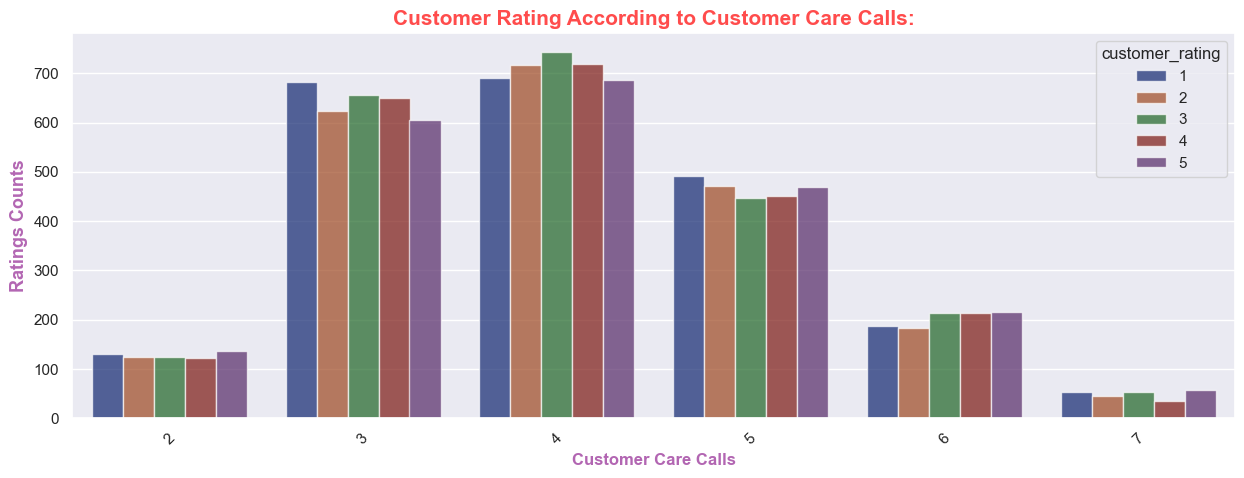

In [73]:
plt.figure(figsize= (15, 5))
sns.barplot(data= sasd, x= "customer_care_calls", y= "count", hue= "customer_rating", palette= "dark", alpha= 0.7)
plt.title("Customer Rating According to Customer Care Calls:", fontsize= 15, fontweight= "bold", color= "red", loc= "center", alpha= 0.7)
plt.xlabel("Customer Care Calls", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.6)
plt.ylabel("Ratings Counts", fontsize= 13, fontweight= "bold", color= "purple", alpha= 0.6)
plt.xticks(rotation= 45)
plt.show()

Since, we are interested in the relative behaviors of different number of customer care calls and the corresponding customer ratings, it is more appropriate to use Normalized values for final analysis:

In [79]:
mcp = data.groupby(by= "customer_care_calls")["customer_rating"].value_counts(normalize= True).reset_index()
mcp.head(3)

,customer_care_calls,customer_rating,proportion
0,2,5,0.213166
1,2,1,0.203762
2,2,3,0.195925


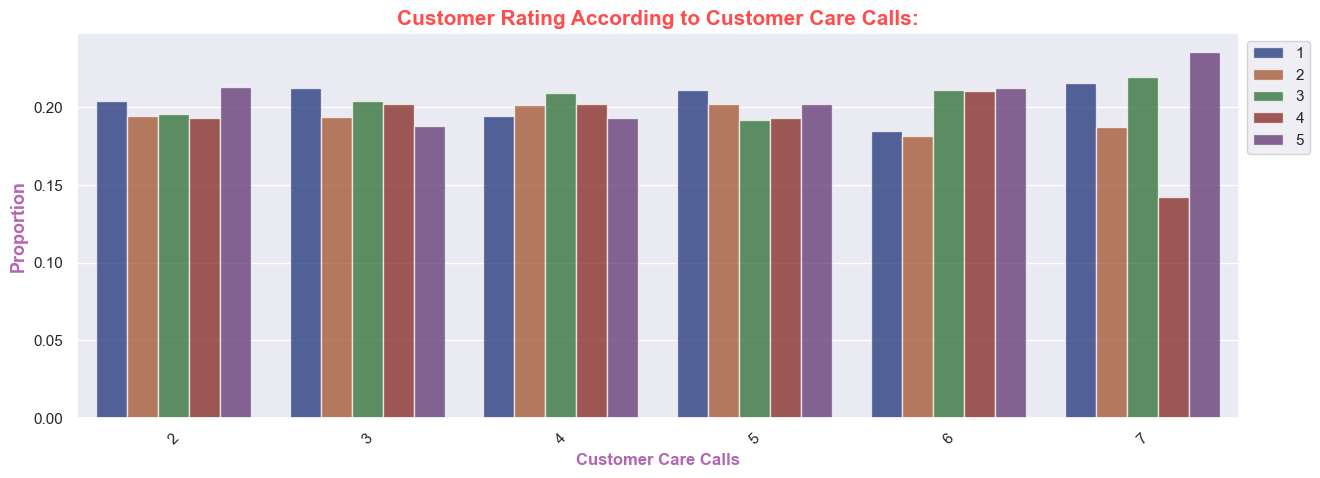

In [77]:
plt.figure(figsize= (15, 5))
sns.barplot(data= mcp, x= "customer_care_calls", y= "proportion", hue= "customer_rating", palette= "dark", alpha= 0.7)
plt.title("Customer Rating According to Customer Care Calls:", fontsize= 15, fontweight= "bold", color= "red", loc= "center", alpha= 0.7)
plt.xlabel("Customer Care Calls", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.6)
plt.ylabel("Proportion", fontsize= 13, fontweight= "bold", color= "purple", alpha= 0.6)
plt.xticks(rotation= 45)
# Plot legend outside the plot: 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

Each bar group represents a different number of customer care calls, and within each group, bars represent the proportion of customers giving each rating. 

The data shows no strong trend linking more customer care calls with consistently better or worse ratings. However, for 7 calls, a noticeably higher proportion of customers gave a rating of 5, while a lower proportion gave a rating of 4, potentially indicating that customers who engage more frequently with customer service might end up more satisfied or are more engaged in general. The distribution of ratings appears relatively uniform across other call frequencies, with slight variations.

In [60]:
data.groupby(by= "customer_care_calls")["customer_rating"].mean().reset_index()

,customer_care_calls,customer_rating
0,2,3.017241
1,3,2.959901
2,4,2.998032
3,5,2.972938
4,6,3.083909
5,7,2.995935


----
----
----

## **14. Discounts and Customer Satisfaction:**

In [81]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [82]:
data.head(3)

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [ ]:
data["discount_offered"] # This is continuous variable

0        44
1        59
2        48
3        10
4        46
         ..
10994     1
10995     6
10996     4
10997     2
10998     6
Name: discount_offered, Length: 10999, dtype: int64

In [ ]:
data["customer_rating"].unique() # treat them as categorical variables 

array([2, 5, 3, 1, 4])

In [92]:
dsa= data.groupby(by= "customer_rating")["discount_offered"].mean().reset_index()
dsa

,customer_rating,discount_offered
0,1,13.458166
1,2,13.687760
2,3,12.979902
3,4,13.257195
4,5,13.494703


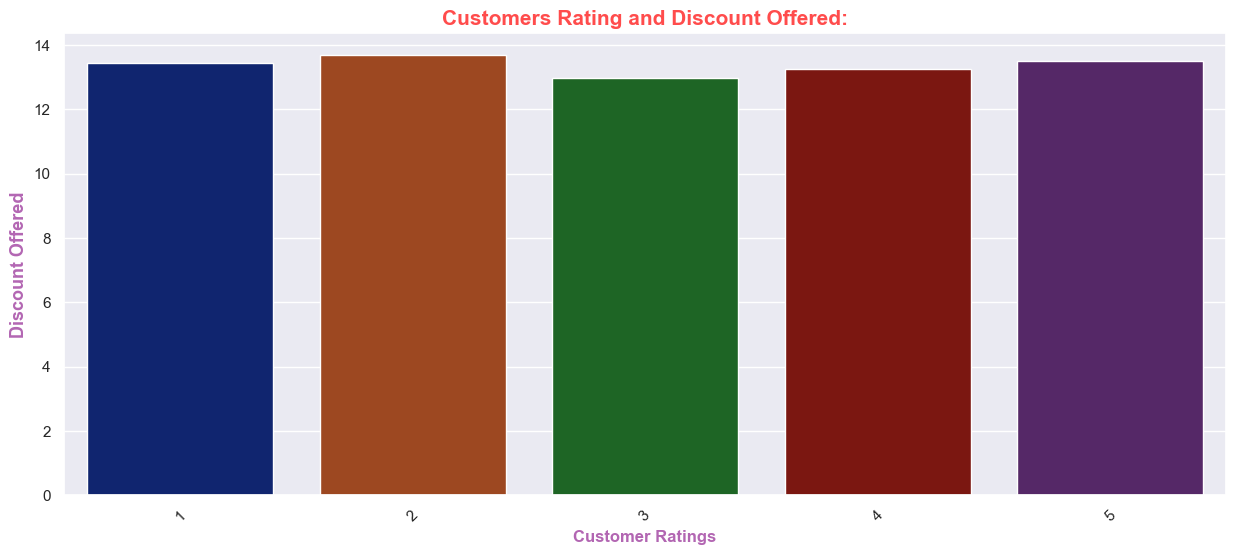

In [97]:
plt.figure(figsize= (15, 6))
sns.set_theme(context= "notebook", style= "darkgrid")
sns.barplot(data= dsa, x= "customer_rating", y= "discount_offered", palette= "dark", hue= "customer_rating", legend= False)
plt.title("Customers Rating and Discount Offered:", color= "red", fontsize= 15, fontweight= "bold", alpha= 0.7)
plt.xlabel("Customer Ratings", color= "purple", fontsize= 12, fontweight= "bold", alpha= 0.6)
plt.ylabel("Discount Offered", color= "purple", fontsize= 13, fontweight= "bold", alpha= 0.6)
plt.xticks(rotation= 45)
plt.show()  

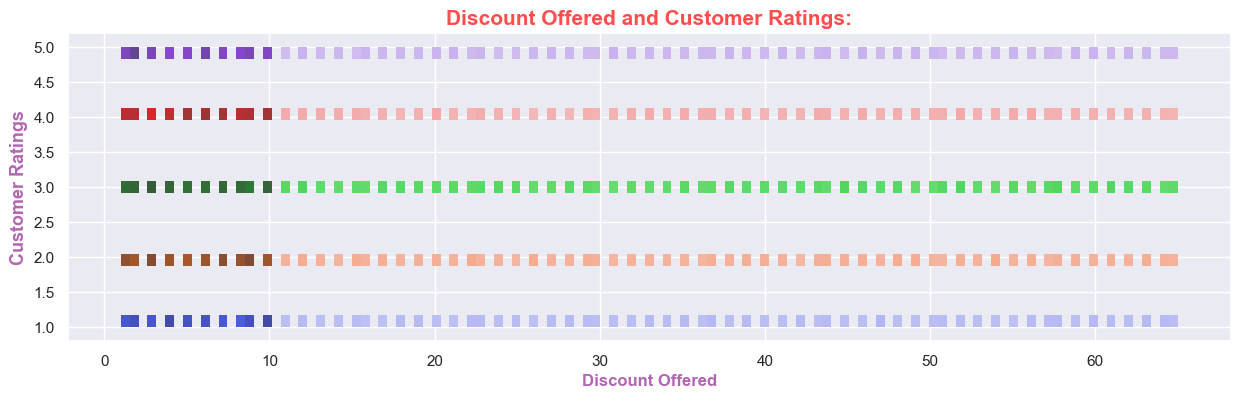

In [110]:
plt.figure(figsize= (15, 4))
sns.histplot(data= data, y= "customer_rating",  x= "discount_offered", palette="bright", hue= "customer_rating", legend= False)
plt.title("Discount Offered and Customer Ratings:", fontsize= 15, fontweight= "bold", color= "red", loc= "center", alpha= 0.7)
plt.xlabel("Discount Offered", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.6)
plt.ylabel("Customer Ratings", fontsize= 13, fontweight= "bold", color= "purple", alpha= 0.6)
plt.show()

In [113]:
data[["discount_offered", "customer_rating"]].corr(method= "spearman")

,discount_offered,customer_rating
discount_offered,1.000000,-0.002299
customer_rating,-0.002299,1.000000


A correlation coefficient $r$ of $-0.002299$, is very close to zero indicating very little to no correlation between discount offered and the customer ratings. 

Offering discounts on products didn't seem to have positive effect on customer ratings.

----
---
----

## **15. Product Importance vs. Customer Rating:**  

In [114]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [ ]:
data["product_importance"].unique() #categories

array(['low', 'medium', 'high'], dtype=object)

In [116]:
data["customer_rating"].unique()

array([2, 5, 3, 1, 4])

In [119]:
mean_rating= data.groupby(by= "product_importance")["customer_rating"].mean().reset_index(name= "mean_rating")
mean_rating

,product_importance,mean_rating
0,high,2.993671
1,low,2.983576
2,medium,2.997686


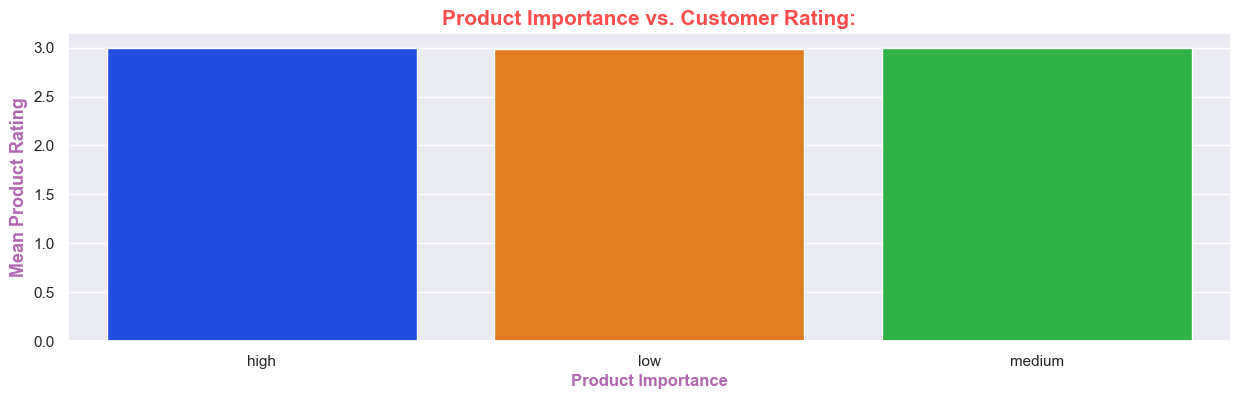

In [123]:
plt.figure(figsize= (15, 4))
sns.barplot(data= mean_rating, y= "mean_rating",  x= "product_importance", palette="bright", hue= "product_importance", legend= False)
plt.title("Product Importance vs. Customer Rating:", fontsize= 15, fontweight= "bold", color= "red", loc= "center", alpha= 0.7)
plt.xlabel("Product Importance", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.6)
plt.ylabel("Mean Product Rating", fontsize= 13, fontweight= "bold", color= "purple", alpha= 0.6)
plt.show()

In [131]:
robust_rating= data.groupby(by= "product_importance")["customer_rating"].value_counts(normalize= True).reset_index(name= "mean_rating")
robust_rating.sample(5)

,product_importance,customer_rating,mean_rating
1,high,4,0.203586
14,medium,1,0.196045
7,low,3,0.198981
2,high,1,0.196203
8,low,5,0.198414


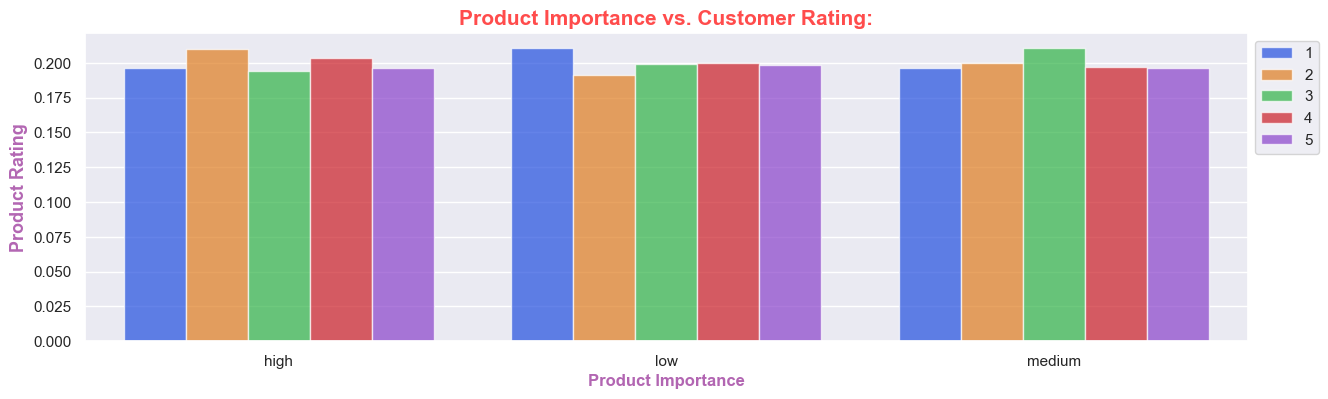

In [130]:
plt.figure(figsize= (15, 4))
sns.barplot(data= robust_rating, y= "mean_rating",  x= "product_importance", palette="bright", hue= "customer_rating", legend= True, alpha= 0.7)
plt.title("Product Importance vs. Customer Rating:", fontsize= 15, fontweight= "bold", color= "red", loc= "center", alpha= 0.7)
plt.xlabel("Product Importance", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.6)
plt.ylabel("Product Rating", fontsize= 13, fontweight= "bold", color= "purple", alpha= 0.6)
# plot legend outside the main plot: 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

While giving ratings of the products, customers did not care if the product is of high importance of not. Ratings for all product categories (by importance) are almost identical.